In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import constants
from IPython.display import display, Latex
from utils.latex import render_latex
from utils.rounding import round_unc_pdg

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
        "figure.titlesize": 18,
        "figure.figsize": (10, 6),
    }
)

DATA_DIR = Path("data")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
samples = ["0_1", "1_0", "hmin", "lmin", "water", "unknownmin"]
sample_labels = {
    "0_1": "0.1 M CuSO$_4$",
    "1_0": "1.0 M CuSO$_4$",
    "hmin": "Heavy Mineral Oil",
    "lmin": "Light Mineral Oil",
    "water": "Water",
    "unknownmin": "Unknown Mineral Oil",
}

t1_negation_threshold = {  # ms
    "0_1": 3.3,
    "1_0": 0.55,
    "hmin": 22,
    "lmin": 47,
    "water": 0.9,
    "unknownmin": 23.5,
}

t1_uncertainties = {  # M_err: V
    "0_1": {"M_err": 0.5},
    "1_0": {"M_err": 0.5},
    "hmin": {"M_err": 0.1},
    "lmin": {"M_err": 0.2},
    "water": {"M_err": 0.1},
    "unknownmin": {"M_err": 0.5},
}

t2_uncertainties = {  # M_err: V
    "0_1": {"M_err": 0.5},
    "1_0": {"M_err": 0.5},
    "hmin": {"M_err": 0.1},
    "lmin": {"M_err": 0.1},
    "water": {"M_err": 0.1},
    "unknownmin": {"M_err": 0.5},
}

t2_star_values = {  # ms
    "0_1": 0.28,
    "1_0": 0.256,
    "hmin": 0.270,
    "lmin": 0.0,
    "water": 0.0,
    "unknownmin": 0.286,
}

t2_star_uncertainties = {  # ms
    # "0_1": 0.01,
    # "1_0": 0.05,
    # "hmin": 0.05,
    # "lmin": 0.0,
    # "water": 0.0,
    # "unknownmin": 0.05,
}
for key in t2_star_values.keys():
    # 15% uncertainty
    t2_star_uncertainties.update({key: t2_star_values[key] * 0.15})

B0_gauss = 3330  # G
B0_gauss_err = 10  # G
B0_tesla = B0_gauss * 1e-4  # T
B0_tesla_err = B0_gauss_err * 1e-4  # T
gamma_rad_s_T = constants.physical_constants["proton gyromag. ratio"][0]  # rad/(s·T)

t1_data = {}
t2_data = {}

for sample in samples:
    t1_data[sample] = pd.read_csv(DATA_DIR / "t1" / f"{sample}.tsv", sep="\t")
    t2_data[sample] = pd.read_csv(DATA_DIR / "t2" / f"{sample}.tsv", sep="\t")

for sample in samples:
    threshold = t1_negation_threshold[sample]
    mask = t1_data[sample]["t"] < threshold
    t1_data[sample].loc[mask, "M"] = -t1_data[sample].loc[mask, "M"]

print("T1 Data (with negation applied):")
for k, v in t1_data.items():
    print(f"  {k}: {len(v)} points, negation threshold: {t1_negation_threshold[k]} ms")

print("\nT2 Data:")
for k, v in t2_data.items():
    print(f"  {k}: {len(v)} points")

T1 Data (with negation applied):
  0_1: 19 points, negation threshold: 3.3 ms
  1_0: 17 points, negation threshold: 0.55 ms
  hmin: 15 points, negation threshold: 22 ms
  lmin: 20 points, negation threshold: 47 ms
  water: 10 points, negation threshold: 0.9 ms
  unknownmin: 44 points, negation threshold: 23.5 ms

T2 Data:
  0_1: 7 points
  1_0: 6 points
  hmin: 10 points
  lmin: 20 points
  water: 5 points
  unknownmin: 11 points


In [3]:
t2_star_uncertainties

{'0_1': 0.042,
 '1_0': 0.0384,
 'hmin': 0.0405,
 'lmin': 0.0,
 'water': 0.0,
 'unknownmin': 0.042899999999999994}

In [4]:
def t2_model(t, M0, T2):
    return M0 * np.exp(-t / T2)


def t1_model(t, M0, T1):
    return M0 * (1 - 2 * np.exp(-t / T1))


def compute_delta_b0(gamma, T2_star, T2, T1):
    return (1 / gamma) * (1 / T2_star - 1 / T2 - 1 / T1)


def compute_delta_b0_uncertainty(gamma, T2_star, T2, T1, T2_star_err, T2_err, T1_err):
    return (1 / np.abs(gamma)) * (
        T2_star_err / T2_star**2 + T2_err / T2**2 + T1_err / T1**2
    )


def safe_round_unc(val, err):
    if not np.isfinite(err) or err <= 0:
        err = abs(val) * 0.1 if val != 0 else 0.01
    return round_unc_pdg(val, err)


def fit_and_plot_t2(sample, data, ax, uncertainties):
    t = data["t"].values
    M = data["M"].values
    M_err = uncertainties["M_err"]

    M_err_arr = np.full_like(M, M_err, dtype=float)

    popt, pcov = curve_fit(
        t2_model, t, M, p0=[M[0], t[-1] / 2], sigma=M_err_arr, absolute_sigma=True
    )

    M0, T2 = popt
    perr = np.sqrt(np.diag(pcov))
    M0_err, T2_err = perr

    t_fit = np.linspace(t.min(), t.max(), 200)
    M_fit = t2_model(t_fit, M0, T2)

    ax.errorbar(
        t, M, yerr=M_err_arr, fmt="o", capsize=3, label="Spin Echo Data", zorder=5
    )
    ax.plot(t_fit, M_fit, "r-", label="Fit", zorder=4)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Signal Amplitude (V)")
    ax.set_title(f"$T_2$ Decay: {sample_labels[sample]}")
    ax.legend(loc="upper right")

    return {
        "sample": sample,
        "T2": T2,
        "T2_err": T2_err if np.isfinite(T2_err) else abs(T2) * 0.1,
        "M0": M0,
        "M0_err": M0_err if np.isfinite(M0_err) else abs(M0) * 0.1,
    }


def fit_and_plot_t1(sample, data, ax, uncertainties):
    t = data["t"].values
    M = data["M"].values
    M_err = uncertainties["M_err"]

    M_err_arr = np.full_like(M, M_err, dtype=float)

    popt, pcov = curve_fit(
        t1_model,
        t,
        M,
        p0=[M.max(), t[np.argmax(M)] / 2],
        sigma=M_err_arr,
        absolute_sigma=True,
    )

    M0, T1 = popt
    perr = np.sqrt(np.diag(pcov))
    M0_err, T1_err = perr

    t_fit = np.linspace(t.min(), t.max(), 200)
    M_fit = t1_model(t_fit, M0, T1)

    ax.errorbar(t, M, yerr=M_err_arr, fmt="o", capsize=3, label="M_z Data", zorder=5)

    ax.plot(t_fit, M_fit, "r-", label="Fit", zorder=4)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Signal Amplitude (V)")
    ax.set_title(f"$T_1$ Recovery: {sample_labels[sample]}")
    ax.legend(loc="lower right")

    return {
        "sample": sample,
        "T1": T1,
        "T1_err": T1_err if np.isfinite(T1_err) else abs(T1) * 0.1,
        "M0": M0,
        "M0_err": M0_err if np.isfinite(M0_err) else abs(M0) * 0.1,
    }

In [ ]:
t2_results = []

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, sample in enumerate(samples):
    result = fit_and_plot_t2(sample, t2_data[sample], axes[i], t2_uncertainties[sample])
    t2_results.append(result)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "t2_fits.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "t2_fits.png", dpi=150, bbox_inches="tight")
plt.show()

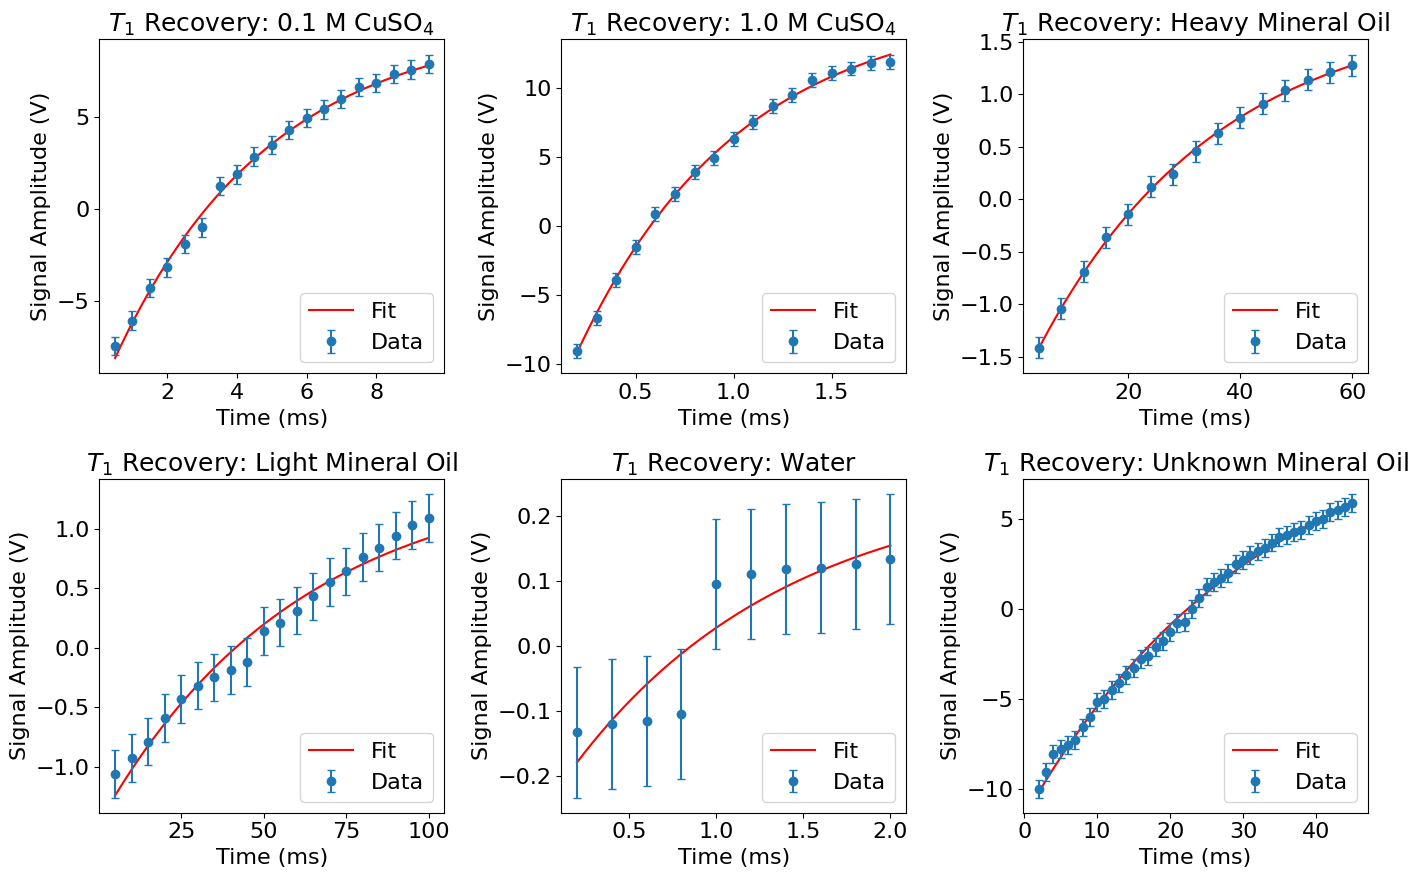

In [ ]:
t1_results = []

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, sample in enumerate(samples):
    result = fit_and_plot_t1(sample, t1_data[sample], axes[i], t1_uncertainties[sample])
    t1_results.append(result)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "t1_fits.pdf", bbox_inches="tight")
plt.savefig(OUTPUT_DIR / "t1_fits.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import math


def relative_field_inhomogeneity_error(delta_B0, B0, err_delta_B0, err_B0):
    R = delta_B0 / B0
    err_R = R * math.sqrt((err_delta_B0 / delta_B0) ** 2 + (err_B0 / B0) ** 2)
    return R, err_R


def longitudinal_transverse_ratio_error(T2_star, T2_star_err, T1, T1_err):
    f = T2_star / T1
    f_err = (T2_star_err / T1) + (T2_star / (T1**2)) * T1_err
    return f, f_err


In [ ]:
sample_names_latex = {
    "0_1": "0.1 M CuSO$_4$",
    "1_0": "1.0 M CuSO$_4$",
    "hmin": "Heavy Mineral Oil",
    "lmin": "Light Mineral Oil",
    "water": "Water",
    "unknownmin": "Unknown Mineral Oil",
}

table_data = []
for t1_res, t2_res in zip(t1_results, t2_results):
    sample = t1_res["sample"]

    T1, T1_err = round_unc_pdg(t1_res["T1"], t1_res["T1_err"])
    T2, T2_err = round_unc_pdg(t2_res["T2"], t2_res["T2_err"])

    T2_star = t2_star_values[sample]
    T2_star_err = t2_star_uncertainties[sample]

    T2_star_rounded, T2_star_err_rounded = (
        round_unc_pdg(T2_star, T2_star_err) if T2_star > 0 else ("N/A", "N/A")
    )

    if T2_star > 0:
        T1_ms = t1_res["T1"]
        T2_ms = t2_res["T2"]
        T1_err_ms = t1_res["T1_err"]
        T2_err_ms = t2_res["T2_err"]

        T1_s = T1_ms * 1e-3
        T2_s = T2_ms * 1e-3
        T2_star_s = T2_star * 1e-3
        T1_err_s = T1_err_ms * 1e-3
        T2_err_s = T2_err_ms * 1e-3
        T2_star_err_s = T2_star_err * 1e-3

        delta_B0_raw = compute_delta_b0(gamma_rad_s_T, T2_star_s, T2_s, T1_s)
        delta_B0_err_raw = compute_delta_b0_uncertainty(
            gamma_rad_s_T, T2_star_s, T2_s, T1_s, T2_star_err_s, T2_err_s, T1_err_s
        )

        delta_B0_tesla, delta_B0_err_tesla = round_unc_pdg(
            delta_B0_raw, delta_B0_err_raw
        )
        # proportion_raw = delta_B0_raw / B0_tesla
        # proportion_err_raw = delta_B0_err_raw / B0_tesla
        proportion_raw, proportion_err_raw = relative_field_inhomogeneity_error(
            delta_B0_raw, B0_tesla, delta_B0_err_raw, B0_tesla_err
        )
        proportion, proportion_err = round_unc_pdg(proportion_raw, proportion_err_raw)
    else:
        delta_B0_tesla = "N/A"
        delta_B0_err_tesla = "N/A"
        proportion = "N/A"
        proportion_err = "N/A"

    table_data.append(
        {
            "Sample": sample_names_latex[sample],
            "T1": T1,
            "T1_err": T1_err,
            "T2": T2,
            "T2_err": T2_err,
            "T2_star": T2_star_rounded,
            "T2_star_err": T2_star_err_rounded,
            "delta_B0": delta_B0_tesla,
            "delta_B0_err": delta_B0_err_tesla,
            "proportion": proportion,
            "proportion_err": proportion_err,
        }
    )

results_df = pd.DataFrame(table_data)
print("Results DataFrame:")
print(f"B₀ = {B0_gauss} G = {B0_tesla} T")
print(f"γ = {gamma_rad_s_T:.3e} rad/(s·T)")
print()
display(results_df)

Results DataFrame:
B₀ = 3330 G = 0.333 T
γ = 2.675e+08 rad/(s·T)



,Sample,T1,T1_err,T2,T2_err,T2_star,T2_star_err,delta_B0,delta_B0_err,proportion,proportion_err
0,0.1 M CuSO$_4$,4.480,0.090,5.600,0.700,0.28,0.04,0.000012,0.000002,0.000036,0.000006
1,1.0 M CuSO$_4$,0.828,0.012,0.790,0.070,0.26,0.04,0.000005,0.000003,0.000016,0.000008
2,Heavy Mineral Oil,32.100,0.800,18.900,1.900,0.27,0.04,0.000013,0.000002,0.000041,0.000006
3,Light Mineral Oil,60.000,3.100,69.000,5.000,N/A,N/A,N/A,N/A,N/A,N/A
4,Water,1.240,0.260,0.026,0.007,N/A,N/A,N/A,N/A,N/A,N/A
5,Unknown Mineral Oil,32.290,0.340,70.000,8.000,0.29,0.04,0.000013,0.000002,0.000039,0.000006


In [ ]:
def format_value_with_uncertainty_scientific(value_str, uncertainty_str):
    """Format value ± uncertainty with consistent scientific notation exponent"""
    import re

    # Check if either value has e-notation
    has_e_notation = "e" in value_str.lower() or "e" in uncertainty_str.lower()

    if not has_e_notation:
        return value_str, uncertainty_str, None

    # Parse value
    val_match = re.match(r"([+-]?\d*\.?\d+)(?:e([+-]?\d+))?", value_str, re.IGNORECASE)
    if not val_match:
        return value_str, uncertainty_str, None

    val_mantissa = float(val_match.group(1))
    val_exp = int(val_match.group(2)) if val_match.group(2) else 0

    # Parse uncertainty
    unc_match = re.match(
        r"([+-]?\d*\.?\d+)(?:e([+-]?\d+))?", uncertainty_str, re.IGNORECASE
    )
    if not unc_match:
        return value_str, uncertainty_str, None

    unc_mantissa = float(unc_match.group(1))
    unc_exp = int(unc_match.group(2)) if unc_match.group(2) else 0

    # Use the value's exponent as the common exponent
    common_exp = val_exp

    # Adjust mantissas to common exponent
    val_adjusted = val_mantissa * (10 ** (val_exp - common_exp))
    unc_adjusted = unc_mantissa * (10 ** (unc_exp - common_exp))

    # Format mantissas (preserve significant figures from original strings)
    val_formatted = f"{val_adjusted:.10g}".rstrip("0").rstrip(".")
    unc_formatted = f"{unc_adjusted:.10g}".rstrip("0").rstrip(".")

    return val_formatted, unc_formatted, common_exp


def generate_latex_tabular(data):
    latex = []
    latex.append(r"\begin{tabular}{lccccc}")
    latex.append(r"\hline")
    latex.append(
        r"Sample & $T_1$ (ms) & $T_2$ (ms) & $T_2^*$ (ms) & $\Delta B_0$ (T) & $\Delta B_0 / B_0$ \\"
    )
    latex.append(r"\hline")

    for row in data:
        sample_tex = row["Sample"].replace("$_4$", r"$_4$")
        t1_str = f"${row['T1']} \\pm {row['T1_err']}$"
        t2_str = f"${row['T2']} \\pm {row['T2_err']}$"

        if row["T2_star"] != "N/A":
            t2_star_str = f"${row['T2_star']} \\pm {row['T2_star_err']}$"
        else:
            t2_star_str = "N/A"

        if row["delta_B0"] != "N/A":
            delta_b0_val, delta_b0_err_val, delta_b0_exp = (
                format_value_with_uncertainty_scientific(
                    str(row["delta_B0"]), str(row["delta_B0_err"])
                )
            )
            if delta_b0_exp is not None:
                delta_b0_str = f"$({delta_b0_val} \\pm {delta_b0_err_val}) \\times 10^{{{delta_b0_exp}}}$"
            else:
                delta_b0_str = f"${delta_b0_val} \\pm {delta_b0_err_val}$"

            proportion_val, proportion_err_val, proportion_exp = (
                format_value_with_uncertainty_scientific(
                    str(row["proportion"]), str(row["proportion_err"])
                )
            )
            if proportion_exp is not None:
                proportion_str = f"$({proportion_val} \\pm {proportion_err_val}) \\times 10^{{{proportion_exp}}}$"
            else:
                proportion_str = f"${proportion_val} \\pm {proportion_err_val}$"
        else:
            delta_b0_str = "N/A"
            proportion_str = "N/A"

        latex.append(
            f"{sample_tex} & {t1_str} & {t2_str} & {t2_star_str} & {delta_b0_str} & {proportion_str} \\\\"
        )

    latex.append(r"\hline")
    latex.append(r"\end{tabular}")

    return "\n".join(latex)


latex_tabular = generate_latex_tabular(table_data)

with open(OUTPUT_DIR / "relaxation_times_table.tex", "w") as f:
    f.write(latex_tabular)

print("LaTeX Tabular Preview:")
print("-" * 60)
print(latex_tabular)
print("-" * 60)
print(f"\nTable saved to {OUTPUT_DIR / 'relaxation_times_table.tex'}")


LaTeX Tabular Preview:
------------------------------------------------------------
\begin{tabular}{lccccc}
\hline
Sample & $T_1$ (ms) & $T_2$ (ms) & $T_2^*$ (ms) & $\Delta B_0$ (T) & $\Delta B_0 / B_0$ \\
\hline
0.1 M CuSO$_4$ & $4.48 \pm 0.09$ & $5.6 \pm 0.7$ & $0.28 \pm 0.04$ & $(1.18 \pm 0.21) \times 10^{-5}$ & $(3.6 \pm 0.6) \times 10^{-5}$ \\
1.0 M CuSO$_4$ & $0.828 \pm 0.012$ & $0.79 \pm 0.07$ & $0.26 \pm 0.04$ & $(5.3 \pm 2.7) \times 10^{-6}$ & $(1.6 \pm 0.8) \times 10^{-5}$ \\
Heavy Mineral Oil & $32.1 \pm 0.8$ & $18.9 \pm 1.9$ & $0.27 \pm 0.04$ & $(1.35 \pm 0.21) \times 10^{-5}$ & $(4.1 \pm 0.6) \times 10^{-5}$ \\
Light Mineral Oil & $60.0 \pm 3.1$ & $69.0 \pm 5.0$ & N/A & N/A & N/A \\
Water & $1.24 \pm 0.26$ & $0.026 \pm 0.007$ & N/A & N/A & N/A \\
Unknown Mineral Oil & $32.29 \pm 0.34$ & $70.0 \pm 8.0$ & $0.29 \pm 0.04$ & $(1.29 \pm 0.2) \times 10^{-5}$ & $(3.9 \pm 0.6) \times 10^{-5}$ \\
\hline
\end{tabular}
------------------------------------------------------------

Tab

In [ ]:
sample_names_display = {
    "0.1 M CuSO$_4$": r"\text{0.1 M CuSO}_4",
    "1.0 M CuSO$_4$": r"\text{1.0 M CuSO}_4",
    "Heavy Mineral Oil": r"\text{Heavy Mineral Oil}",
    "Light Mineral Oil": r"\text{Light Mineral Oil}",
    "Water": r"\text{Water}",
    "Unknown Mineral Oil": r"\text{Unknown Mineral Oil}",
}

display_latex = r"""
\begin{array}{lccccc}
\hline
\textbf{Sample} & \boldsymbol{T_1} \textbf{ (ms)} & \boldsymbol{T_2} \textbf{ (ms)} & \boldsymbol{T_2^*} \textbf{ (ms)} & \boldsymbol{\Delta B_0} \textbf{ (T)} & \boldsymbol{\Delta B_0 / B_0} \\
\hline
"""

for row in table_data:
    sample_display = sample_names_display[row["Sample"]]

    t1_str = f"{row['T1']} \\pm {row['T1_err']}"
    t2_str = f"{row['T2']} \\pm {row['T2_err']}"

    if row["T2_star"] != "N/A":
        t2_star_str = f"{row['T2_star']} \\pm {row['T2_star_err']}"
    else:
        t2_star_str = r"\text{N/A}"

    if row["delta_B0"] != "N/A":
        delta_b0_val, delta_b0_err_val, delta_b0_exp = (
            format_value_with_uncertainty_scientific(
                str(row["delta_B0"]), str(row["delta_B0_err"])
            )
        )
        if delta_b0_exp is not None:
            delta_b0_str = f"({delta_b0_val} \\pm {delta_b0_err_val}) \\times 10^{{{delta_b0_exp}}}"
        else:
            delta_b0_str = f"{delta_b0_val} \\pm {delta_b0_err_val}"

        proportion_val, proportion_err_val, proportion_exp = (
            format_value_with_uncertainty_scientific(
                str(row["proportion"]), str(row["proportion_err"])
            )
        )
        if proportion_exp is not None:
            proportion_str = f"({proportion_val} \\pm {proportion_err_val}) \\times 10^{{{proportion_exp}}}"
        else:
            proportion_str = f"{proportion_val} \\pm {proportion_err_val}"
    else:
        delta_b0_str = r"\text{N/A}"
        proportion_str = r"\text{N/A}"

    display_latex += f"{sample_display} & {t1_str} & {t2_str} & {t2_star_str} & {delta_b0_str} & {proportion_str} \\\\\n"

display_latex += r"""
\hline
\end{array}
"""

print("Rendered Table Preview:")
render_latex(f"$${display_latex}$$")


Rendered Table Preview:


<IPython.core.display.Latex object>

In [ ]:
export_df = pd.DataFrame(
    [
        {
            "Sample": row["Sample"],
            "T1_ms": row["T1"],
            "T1_err_ms": row["T1_err"],
            "T2_ms": row["T2"],
            "T2_err_ms": row["T2_err"],
            "T2_star_ms": row["T2_star"],
            "T2_star_err_ms": row["T2_star_err"],
            "delta_B0_T": row["delta_B0"],
            "delta_B0_err_T": row["delta_B0_err"],
            "proportion": row["proportion"],
            "proportion_err": row["proportion_err"],
        }
        for row in table_data
    ]
)
export_df.to_csv(OUTPUT_DIR / "relaxation_times.csv", index=False)
print(f"Results saved to {OUTPUT_DIR / 'relaxation_times.csv'}")
display(export_df)


Results saved to output/relaxation_times.csv


,Sample,T1_ms,T1_err_ms,T2_ms,T2_err_ms,T2_star_ms,T2_star_err_ms,delta_B0_T,delta_B0_err_T,proportion,proportion_err
0,0.1 M CuSO$_4$,4.480,0.090,5.600,0.700,0.28,0.04,0.000012,0.000002,0.000036,0.000006
1,1.0 M CuSO$_4$,0.828,0.012,0.790,0.070,0.26,0.04,0.000005,0.000003,0.000016,0.000008
2,Heavy Mineral Oil,32.100,0.800,18.900,1.900,0.27,0.04,0.000013,0.000002,0.000041,0.000006
3,Light Mineral Oil,60.000,3.100,69.000,5.000,N/A,N/A,N/A,N/A,N/A,N/A
4,Water,1.240,0.260,0.026,0.007,N/A,N/A,N/A,N/A,N/A,N/A
5,Unknown Mineral Oil,32.290,0.340,70.000,8.000,0.29,0.04,0.000013,0.000002,0.000039,0.000006


In [ ]:
# Compare T2_star with T1.

export_df_valid = export_df[export_df["T2_star_ms"] != "N/A"].copy()

T2_star_over_T1, T2_star_over_T1_err = longitudinal_transverse_ratio_error(
    export_df_valid["T2_star_ms"],
    export_df_valid["T2_star_err_ms"],
    export_df_valid["T1_ms"],
    export_df_valid["T1_err_ms"],
)

export_df_valid["T2_star_over_T1"], export_df_valid["T2_star_over_T1_err"] = (
    round_unc_pdg(T2_star_over_T1, T2_star_over_T1_err)
)


In [ ]:
print(export_df_valid.to_string(index=False))

             Sample  T1_ms  T1_err_ms  T2_ms  T2_err_ms T2_star_ms T2_star_err_ms delta_B0_T delta_B0_err_T proportion proportion_err  T2_star_over_T1  T2_star_over_T1_err
     0.1 M CuSO$_4$  4.480      0.090   5.60       0.70       0.28           0.04   0.000012       0.000002   0.000036       0.000006           0.0620               0.0100
     1.0 M CuSO$_4$  0.828      0.012   0.79       0.07       0.26           0.04   0.000005       0.000003   0.000016       0.000008           0.3100               0.0500
  Heavy Mineral Oil 32.100      0.800  18.90       1.90       0.27           0.04   0.000013       0.000002   0.000041       0.000006           0.0084               0.0015
Unknown Mineral Oil 32.290      0.340  70.00       8.00       0.29           0.04   0.000013       0.000002   0.000039       0.000006           0.0090               0.0013
